In [37]:
import cv2
import numpy as np
import shutil
import yaml
from pathlib import Path

In [38]:
BASE_DIR   = Path(".")

ORIG_TRAIN = BASE_DIR / "1. Original Images" / "a. Training Set"
ORIG_VAL   = BASE_DIR / "1. Original Images" / "b. Testing Set"

GT_BASE_TRAIN = BASE_DIR / "2. All Segmentation Groundtruths" / "a. Training Set"
GT_BASE_VAL   = BASE_DIR / "2. All Segmentation Groundtruths" / "b. Testing Set"

GT_SE_TRAIN = GT_BASE_TRAIN / "4. Soft Exudates"
GT_OD_TRAIN = GT_BASE_TRAIN / "5. Optic Disc"
GT_HE_TRAIN = GT_BASE_TRAIN / "3. Hard Exudates"

GT_SE_VAL   = GT_BASE_VAL / "4. Soft Exudates"
GT_OD_VAL   = GT_BASE_VAL / "5. Optic Disc"
GT_HE_VAL   = GT_BASE_VAL / "3. Hard Exudates"

OUTPUT_DIR  = Path("yolo_dataset")

# Class ID untuk YOLO
# Kita hanya segmentasi SE, jadi hanya 1 class
CLASS_SE = 0

### Cek gambar dulu, gimana kalau diubah ke grayscale

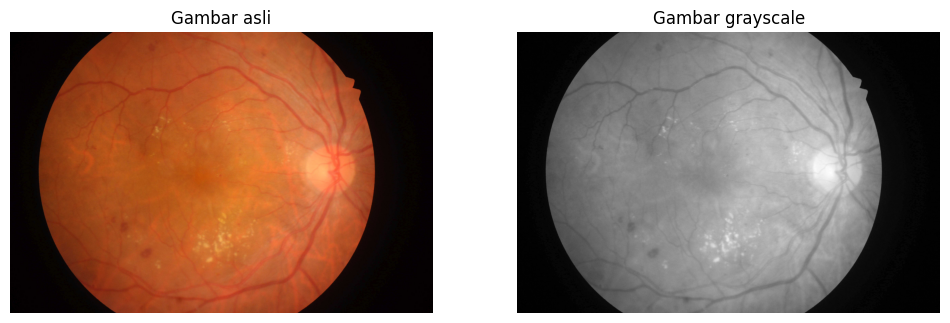

In [39]:
import matplotlib.pyplot as plt
import cv2

tif_path = "1. Original Images/a. Training Set/IDRiD_01.jpg"

img = cv2.imread(tif_path)

if img is not None:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Gambar asli')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gray_img, cmap='gray')
    plt.title('Gambar grayscale')
    plt.axis('off')

    plt.show()



### Convert tif image, ambil data binary masknya saja

In [41]:
def load_binary_mask(tif_path):
    img = cv2.imread(str(tif_path))
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 10, 1, cv2.THRESH_BINARY)
    return binary.astype(np.uint8)

In [42]:
def apply_removal(image_bgr, od_mask, he_mask):
    """
    Hapus OD dan HE dari gambar menggunakan ground truth mask.
    Pakai inpainting agar hasilnya natural.
    
    Return: gambar BGR dengan OD dan HE di-inpaint
    """
    result = image_bgr.copy()
    
    # Gabungkan OD + HE mask untuk inpainting sekaligus
    combined_mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    
    if od_mask is not None:
        combined_mask = cv2.bitwise_or(combined_mask, od_mask)
    if he_mask is not None:
        combined_mask = cv2.bitwise_or(combined_mask, he_mask)
    
    # Hanya inpaint jika ada area yang perlu dihapus
    if combined_mask.sum() > 0:
        result = cv2.inpaint(
            result,
            combined_mask,
            inpaintRadius=5,
            flags=cv2.INPAINT_TELEA
        )
    
    return result


In [43]:

def mask_to_yolo_polygons(binary_mask, img_w, img_h, min_area=50):

    lines = []
    
    # Cari semua contour (tiap contour = 1 blob SE)
    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,      # hanya outer contour
        cv2.CHAIN_APPROX_SIMPLE # kompres titik berurutan
    )
    
    for contour in contours:
        # Skip blob yang terlalu kecil (kemungkinan noise)
        area = cv2.contourArea(contour)
        if area < min_area:
            continue
        
        # Simplify contour agar tidak terlalu banyak titik
        # epsilon = 0.002 * perimeter → kontrol tingkat simplifikasi
        epsilon = 0.002 * cv2.arcLength(contour, closed=True)
        simplified = cv2.approxPolyDP(contour, epsilon, closed=True)
        
        # Minimal 3 titik untuk membentuk poligon
        if len(simplified) < 3:
            continue
        
        # Flatten dan normalisasi koordinat ke 0-1
        points = simplified.reshape(-1, 2).astype(float)
        points[:, 0] /= img_w   # normalisasi x
        points[:, 1] /= img_h   # normalisasi y
        
        # Clip ke range 0-1 (jaga-jaga kalau ada nilai di luar)
        points = np.clip(points, 0.0, 1.0)
        
        # Format YOLO: "class_id x1 y1 x2 y2 ..."
        coords_str = " ".join([f"{x:.6f} {y:.6f}" for x, y in points])
        line = f"{CLASS_SE} {coords_str}"
        lines.append(line)
    
    return lines

In [ ]:

def process_split(orig_dir, gt_se_dir, gt_od_dir, gt_he_dir, out_img_dir, out_lbl_dir, split_name):
    """
    Proses satu split (train atau val):
    1. Copy/proses gambar ke out_img_dir
    2. Buat file label YOLO di out_lbl_dir
    """
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)
    
    # Ambil semua gambar original
    orig_files = sorted(Path(orig_dir).glob("*.jpg"))
    if not orig_files:
        orig_files = sorted(Path(orig_dir).glob("*.JPG"))
    
    print(f"\n  [{split_name}] {len(orig_files)} gambar ditemukan")
    
    stats = {
        'total'         : len(orig_files),
        'with_se'       : 0,
        'without_se'    : 0,
        'total_instances': 0,
    }
    
    for orig_path in orig_files:
        stem = orig_path.stem  # misal: IDRiD_03
        
        # ── Load gambar original ──────────────────────────────
        image_bgr = cv2.imread(str(orig_path))
        if image_bgr is None:
            print(f"    ⚠️  Tidak bisa load: {orig_path.name}")
            continue
        
        img_h, img_w = image_bgr.shape[:2]
        
        # ── Load ground truth masks ───────────────────────────
        se_path = Path(gt_se_dir) / f"{stem}_SE.tif"
        od_path = Path(gt_od_dir) / f"{stem}_OD.tif"
        he_path = Path(gt_he_dir) / f"{stem}_HE.tif"
        
        se_mask = load_binary_mask(se_path) if se_path.exists() else None
        od_mask = load_binary_mask(od_path) if od_path.exists() else None
        he_mask = load_binary_mask(he_path) if he_path.exists() else None
        
        # ── Apply OD + HE removal via inpainting ──────────────
        clean_image = apply_removal(image_bgr, od_mask, he_mask)
        
        # ── Simpan gambar hasil removal ───────────────────────
        out_img_path = out_img_dir / f"{stem}.jpg"
        cv2.imwrite(str(out_img_path), clean_image,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        
        # ── Konversi SE mask ke label YOLO ────────────────────
        out_lbl_path = out_lbl_dir / f"{stem}.txt"
        
        if se_mask is not None and se_mask.sum() > 0:
            yolo_lines = mask_to_yolo_polygons(se_mask, img_w, img_h)
            
            if yolo_lines:
                with open(out_lbl_path, 'w') as f:
                    f.write("\n".join(yolo_lines))
                
                stats['with_se']        += 1
                stats['total_instances'] += len(yolo_lines)
                print(f"    ✅ {stem}.jpg → {len(yolo_lines)} instance SE")
            else:
                # Mask ada tapi semua blob terlalu kecil → empty label
                out_lbl_path.touch()
                stats['without_se'] += 1
                print(f"    ⚪ {stem}.jpg → blob SE terlalu kecil, label kosong")
        else:
            # Tidak ada SE → buat file label kosong
            # (YOLO perlu file .txt meski kosong)
            out_lbl_path.touch()
            stats['without_se'] += 1
    
    print(f"\n  [{split_name}] Ringkasan:")
    print(f"    Total gambar          : {stats['total']}")
    print(f"    Gambar dengan SE      : {stats['with_se']}")
    print(f"    Gambar tanpa SE       : {stats['without_se']}")
    print(f"    Total instance SE     : {stats['total_instances']}")
    if stats['with_se'] > 0:
        avg = stats['total_instances'] / stats['with_se']
        print(f"    Rata-rata instance/gambar: {avg:.1f}")
    
    return stats


In [ ]:

def create_yaml(output_dir, train_stats, val_stats):
    """Buat file data.yaml untuk YOLO training"""
    yaml_content = {
        'path'  : str(output_dir.resolve()),
        'train' : 'images/train',
        'val'   : 'images/val',
        'nc'    : 1,
        'names' : ['soft_exudate'],
    }
    
    yaml_path = output_dir / "data.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)
    
    print(f"\n  ✅ data.yaml dibuat: {yaml_path}")
    print(f"     Isi:")
    print(f"       path  : {yaml_content['path']}")
    print(f"       train : {yaml_content['train']}")
    print(f"       val   : {yaml_content['val']}")
    print(f"       nc    : {yaml_content['nc']}")
    print(f"       names : {yaml_content['names']}")



In [45]:

def verify_output(output_dir):
    """Verifikasi hasil konversi"""
    print("\n" + "=" * 60)
    print("VERIFIKASI OUTPUT")
    print("=" * 60)
    
    for split in ['train', 'val']:
        img_dir = output_dir / "images" / split
        lbl_dir = output_dir / "labels" / split
        
        imgs   = list(img_dir.glob("*.jpg"))
        labels = list(lbl_dir.glob("*.txt"))
        
        # Cek label non-kosong
        non_empty = [l for l in labels if l.stat().st_size > 0]
        
        print(f"\n  [{split}]")
        print(f"    Gambar : {len(imgs)}")
        print(f"    Label  : {len(labels)}")
        print(f"    Label non-kosong (ada SE): {len(non_empty)}")
        
        # Cek konsistensi
        img_stems = {f.stem for f in imgs}
        lbl_stems = {f.stem for f in labels}
        
        missing_labels = img_stems - lbl_stems
        if missing_labels:
            print(f"    ⚠️  Gambar tanpa label: {missing_labels}")
        else:
            print(f"    ✅ Semua gambar punya file label")
        
        # Tampilkan 2 contoh label non-kosong
        if non_empty:
            print(f"\n    Contoh isi label ({non_empty[0].name}):")
            with open(non_empty[0]) as f:
                lines = f.readlines()
            for line in lines[:2]:
                tokens = line.strip().split()
                print(f"      class={tokens[0]}, {len(tokens)-1} koordinat "
                    f"({(len(tokens)-1)//2} titik poligon)")

In [47]:

if __name__ == "__main__":
    print("=" * 60)
    print("KONVERSI DATASET IDRiD → FORMAT YOLO SEGMENTASI")
    print("=" * 60)
    
    # Buat struktur folder output
    out_img_train = OUTPUT_DIR / "images" / "train"
    out_img_val   = OUTPUT_DIR / "images" / "val"
    out_lbl_train = OUTPUT_DIR / "labels" / "train"
    out_lbl_val   = OUTPUT_DIR / "labels" / "val"
    
    print("\nMemproses training set...")
    train_stats = process_split(
        orig_dir   = ORIG_TRAIN,
        gt_se_dir  = GT_SE_TRAIN,
        gt_od_dir  = GT_OD_TRAIN,
        gt_he_dir  = GT_HE_TRAIN,
        out_img_dir= out_img_train,
        out_lbl_dir= out_lbl_train,
        split_name = "TRAIN",
    )
    
    print("\nMemproses validation set...")
    val_stats = process_split(
        orig_dir   = ORIG_VAL,
        gt_se_dir  = GT_SE_VAL,
        gt_od_dir  = GT_OD_VAL,
        gt_he_dir  = GT_HE_VAL,
        out_img_dir= out_img_val,
        out_lbl_dir= out_lbl_val,
        split_name = "VAL",
    )
    
    print("\nMembuat data.yaml...")
    create_yaml(OUTPUT_DIR, train_stats, val_stats)
    
    verify_output(OUTPUT_DIR)
    
    print("\n" + "=" * 60)
    print("✅ KONVERSI SELESAI")
    print(f"   Dataset YOLO tersimpan di: {OUTPUT_DIR.resolve()}")
    print("=" * 60)
    print("""
📋 LANGKAH SELANJUTNYA:
   1. Cek folder yolo_dataset/ — pastikan struktur benar
   2. Buka beberapa gambar di images/train/ — pastikan OD & HE sudah hilang
   3. Kalau semua oke → jalankan train_yolo.py untuk mulai training
""")





KONVERSI DATASET IDRiD → FORMAT YOLO SEGMENTASI

Memproses training set...

  [TRAIN] 54 gambar ditemukan
    ✅ IDRiD_03.jpg → 1 instance SE
    ✅ IDRiD_08.jpg → 3 instance SE
    ✅ IDRiD_13.jpg → 8 instance SE
    ✅ IDRiD_14.jpg → 1 instance SE
    ✅ IDRiD_17.jpg → 7 instance SE
    ✅ IDRiD_18.jpg → 3 instance SE
    ✅ IDRiD_19.jpg → 9 instance SE
    ✅ IDRiD_22.jpg → 6 instance SE
    ✅ IDRiD_23.jpg → 5 instance SE
    ✅ IDRiD_25.jpg → 4 instance SE
    ✅ IDRiD_30.jpg → 2 instance SE
    ✅ IDRiD_31.jpg → 8 instance SE
    ✅ IDRiD_32.jpg → 6 instance SE
    ✅ IDRiD_33.jpg → 1 instance SE
    ✅ IDRiD_35.jpg → 3 instance SE
    ✅ IDRiD_38.jpg → 2 instance SE
    ✅ IDRiD_39.jpg → 10 instance SE
    ✅ IDRiD_46.jpg → 6 instance SE
    ✅ IDRiD_47.jpg → 1 instance SE
    ✅ IDRiD_48.jpg → 5 instance SE
    ✅ IDRiD_49.jpg → 1 instance SE
    ✅ IDRiD_50.jpg → 4 instance SE
    ✅ IDRiD_51.jpg → 7 instance SE
    ✅ IDRiD_52.jpg → 2 instance SE
    ✅ IDRiD_53.jpg → 1 instance SE
    ✅ IDRiD_54.jpg

In [33]:
from pathlib import Path

# Cek nama file SE yang ada
gt_se = Path("2. All Segmentation Groundtruths/a. Training Set/4. Soft Exudates")
se_files = list(gt_se.iterdir())[:3]
print("File SE yang ada:")
for f in se_files:
    print(f"  '{f.name}'")

# Cek nama file original
orig = Path("1. Original Images/a. Training Set")
orig_files = list(orig.iterdir())[:3]
print("\nFile original yang ada:")
for f in orig_files:
    print(f"  '{f.name}'")

# Cek apakah path yang dicari script cocok
print("\nPath yang dicari script:")
for f in orig_files:
    stem = f.stem  # misal: IDRiD_03
    expected = gt_se / f"{stem}_SE.tif"
    print(f"  {expected.name} → exists: {expected.exists()}")

File SE yang ada:
  'IDRiD_08_SE.tif'
  'IDRiD_32_SE.tif'
  'IDRiD_51_SE.tif'

File original yang ada:
  'IDRiD_27.jpg'
  'IDRiD_33.jpg'
  'fcnBPDFHE.m'

Path yang dicari script:
  IDRiD_27_SE.tif → exists: False
  IDRiD_33_SE.tif → exists: True
  fcnBPDFHE_SE.tif → exists: False


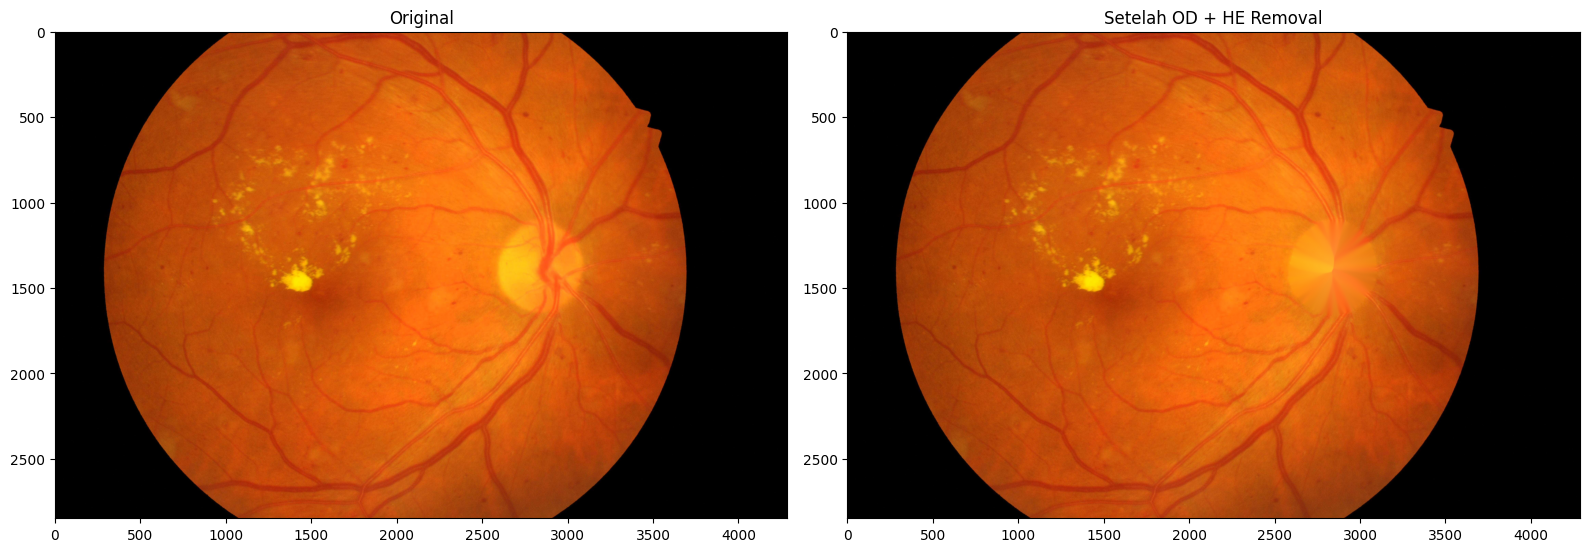

In [49]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Bandingkan original vs hasil removal
orig = cv2.imread("1. Original Images/a. Training Set/IDRiD_13.jpg")
clean = cv2.imread("yolo_dataset/images/train/IDRiD_13.jpg")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
axes[1].set_title("Setelah OD + HE Removal")
plt.tight_layout()
plt.savefig("cek_removal.png", dpi=150)
plt.show()

In [35]:
import cv2
import numpy as np
from pathlib import Path

# Cek ukuran area OD di gambar ini
od_path = Path("2. All Segmentation Groundtruths/a. Training Set/5. Optic Disc/IDRiD_13_OD.tif")
he_path = Path("2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_13_HE.tif")

od = cv2.imread(str(od_path), cv2.IMREAD_GRAYSCALE)
he = cv2.imread(str(he_path), cv2.IMREAD_GRAYSCALE)

print(f"Gambar ukuran: 4288 x 2848")
print(f"OD mask — file exists: {od_path.exists()}")
print(f"HE mask — file exists: {he_path.exists()}")

if od is not None:
    _, od_bin = cv2.threshold(od, 10, 1, cv2.THRESH_BINARY)
    print(f"OD piksel positif: {od_bin.sum()} piksel")
    
if he is not None:
    _, he_bin = cv2.threshold(he, 10, 1, cv2.THRESH_BINARY)
    print(f"HE piksel positif: {he_bin.sum()} piksel")

Gambar ukuran: 4288 x 2848
OD mask — file exists: True
HE mask — file exists: False
OD piksel positif: 216047 piksel


[ WARN:0@16836.458] global loadsave.cpp:278 findDecoder imread_('2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/IDRiD_13_HE.tif'): can't open/read file: check file path/integrity


In [36]:
from pathlib import Path

gt_train = Path("2. All Segmentation Groundtruths/a. Training Set")
for f in gt_train.iterdir():
    print(f"'{f.name}'")


'5. Optic Disc'
'2. Haemorrhages'
'3. Hard Exudates'
'4. Soft Exudates'
'1. Microaneurysms'
